<a href="https://colab.research.google.com/github/imtiyajali11/NLP/blob/main/Simple_RNN_with_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Here is the Sentiment Analysis Using RNN

In [113]:
# Import All libraries



import re
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import precision_score, recall_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, Dense, SimpleRNN
from tensorflow.keras import Sequential

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Step 1: Install the Kaggle API client

In [30]:
#pip install kaggle

### Step 2: Upload Kaggle credential and configure before loading the final dataset


In [31]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"alienster","key":"8e124dcd1bade9e82a77131084c9c947"}'}

# Kaggle setup and download
Run this after uploading the kaggle.json


In [32]:
#2. Series of commands to set-up for download

!ls -lha kaggle.json
!pip install -q kaggle # installing the kaggle package
!mkdir -p ~/.kaggle # creating .kaggle folder where the key should be placed
!cp kaggle.json ~/.kaggle/ # move the key to the folder
!pwd # checking the present working directory

-rw-r--r-- 1 root root 65 Jul  9 10:56 kaggle.json
/content


In [34]:
#3. giving rw access (if 401-nathorized)

!chmod 600 ~/.kaggle/kaggle.json


In [39]:
#4. Sanity check if able to access kaggle
!kaggle datasets list

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset  FIFA World Cup 2026 Player Performance Dataset        4154062  2026-06-10 12:58:47.093000           9905        240                1  
ashyou09/apple-products-pricing-dataset-2020-2026               Apple Products Pricing Dataset (2020-2026)🍎           1569012  2026-07-04 16:06:56.590000           1118         20                1  
arjunmehta1992/chocolate-sales-in-20222023                      Chocolate Sales in 2022–2023                          4820417  2026-06-21 03:52:16.600000           3467         48                1  
sunil

In [40]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rowemorehouse/googleplaystoreuserreviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'googleplaystoreuserreviews' dataset.
Path to dataset files: /kaggle/input/googleplaystoreuserreviews


In [42]:
data = pd.read_csv("/kaggle/input/googleplaystoreuserreviews/googleplaystore_user_reviews.csv")

In [43]:
data.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [49]:
data.drop(['App'], axis= 1, inplace= True)    # Drop unwanted columns for further data preprocessing

data.drop(['Sentiment_Polarity'], axis= 1,inplace= True)    # Drop unwanted columns for further data preprocessing

data.drop(['Sentiment_Subjectivity'], axis= 1, inplace= True)    # Drop unwanted columns for further data preprocessing

data.head()


,Translated_Review,Sentiment
0,I like eat delicious food. That's I'm cooking ...,Positive
1,This help eating healthy exercise regular basis,Positive
2,NaN,NaN
3,Works great especially going grocery store,Positive
4,Best idea us,Positive


In [50]:
# checking for any null or emptpy values

data.isnull().sum()

,0
Translated_Review,26868
Sentiment,26863


In [51]:
data.columns = ['review', 'sentiment']
data.head()

,review,sentiment
0,I like eat delicious food. That's I'm cooking ...,Positive
1,This help eating healthy exercise regular basis,Positive
2,NaN,NaN
3,Works great especially going grocery store,Positive
4,Best idea us,Positive


In [52]:
# Basic EDA

#Checking the data values and columns

data.shape

(64295, 2)

In [53]:
# drop null values

data.dropna(inplace= True)

In [54]:
# checking for any null or emptpy values

data.isnull().sum()

,0
review,0
sentiment,0


In [56]:
# chec the balance of the output column (sentiment)

data['sentiment'].value_counts(normalize= True)

,proportion
sentiment,
Positive,0.641195
Negative,0.220990
Neutral,0.137815


<Axes: xlabel='sentiment'>

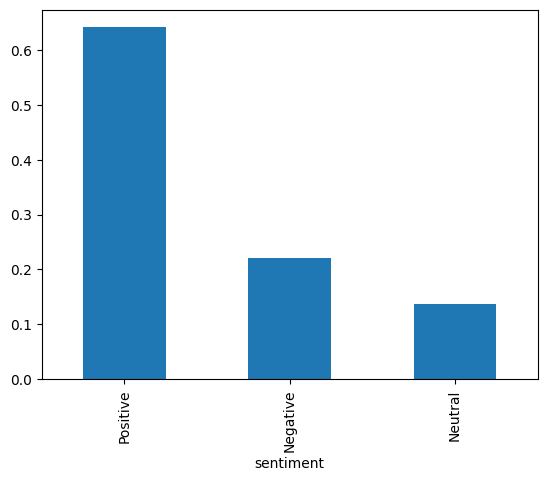

In [68]:
# Lets plot the graph of it to show the value distribution

bar_plot = data['sentiment'].value_counts(normalize= True).plot.bar()
#area_plot = data['sentiment'].value_counts(normalize= True).plot.area()
#print(bar_plot,area_plot)
bar_plot

<Axes: xlabel='sentiment'>

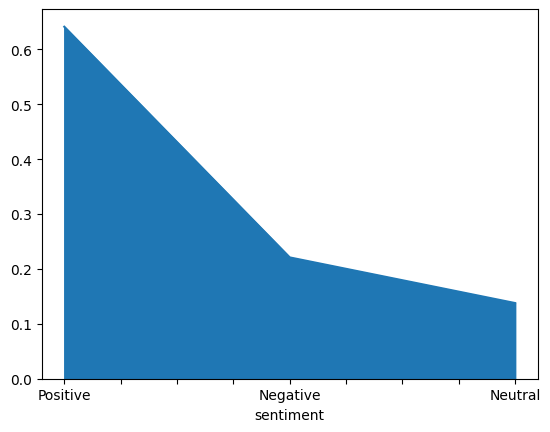

In [61]:

data['sentiment'].value_counts(normalize= True).plot.area()

<Axes: ylabel='sentiment'>

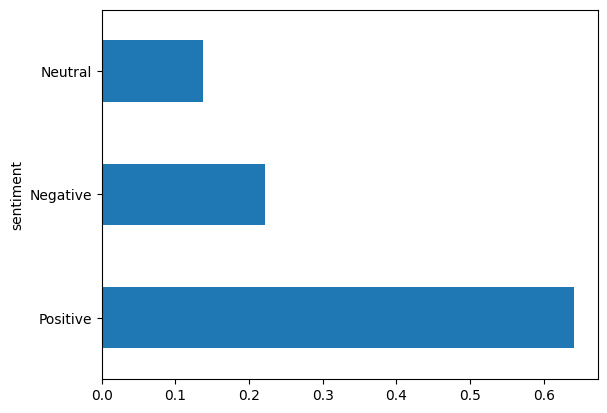

In [69]:

data['sentiment'].value_counts(normalize= True).plot.barh()

### Visualize Sentiment Distribution with Countplot

/tmp/ipykernel_1050/2676225781.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=data, palette='viridis')


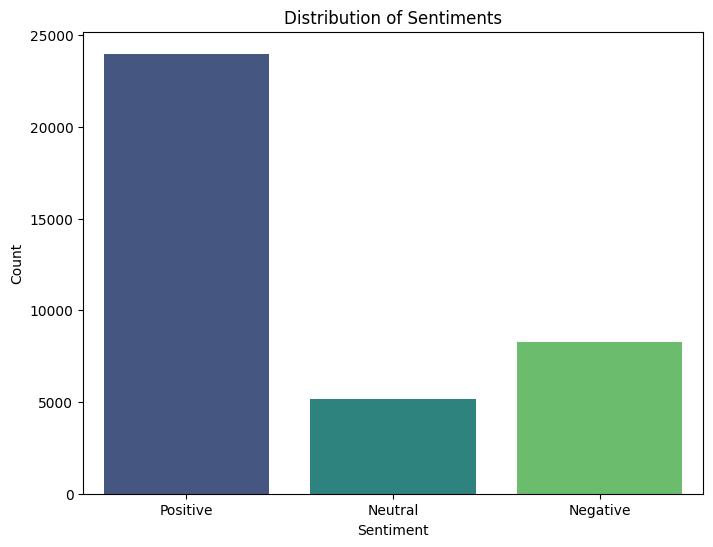

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a countplot for the 'sentiment' column
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=data, palette='viridis')
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

### Word Cloud of Reviews

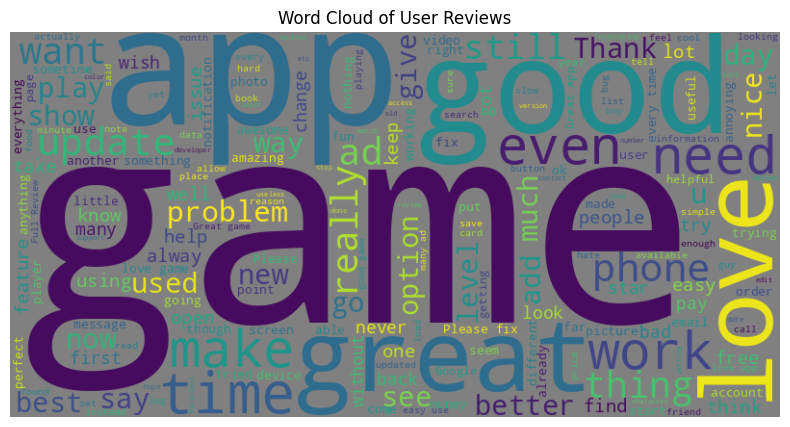

In [85]:
# # Ensure the wordcloud library is installed
# %pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all reviews into a single string, handling potential non-string types
all_reviews_text = ' '.join(data['review'].astype(str).tolist())

# Generate a word cloud
# It can be customized parameters like width, height, background_color, max_words, etc.
wordcloud = WordCloud(width=800, height=400, background_color='Grey').generate(all_reviews_text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Do not show axes frames
plt.title('Word Cloud of User Reviews')
plt.show()

# Text preprocessing

In [114]:
lemmatizer = WordNetLemmatizer()

corpus = []
text_list = list(data['review'])
text_list

['I like eat delicious food. That\'s I\'m cooking food myself, case "10 Best Foods" helps lot, also "Best Before (Shelf Life)"',
 'This help eating healthy exercise regular basis',
 'Works great especially going grocery store',
 'Best idea us',
 'Best way',
 'Amazing',
 'Looking forward app,',
 'It helpful site ! It help foods get !',
 'good you.',
 'Useful information The amount spelling errors questions validity information shared. Once fixed, 5 stars given.',
 'Thank you! Great app!! Add arthritis, eyes, immunity, kidney/liver detox foods please. :)',
 'Greatest ever Completely awesome maintain health.... This must ppl there... Love it!!!',
 'Good health...... Good health first priority.......',
 "Health It's important world either life . think? :)",
 'Mrs sunita bhati I thankful developers,to make kind app, really good healthy food body',
 'Very Useful in diabetes age 30. I need control sugar. thanks',
 'One greatest apps.',
 'good nice',
 'Healthy Really helped',
 'God health',
 '

In [118]:
# to remove all unwanted stuff from the list and create clean list
import nltk
nltk.download('wordnet')

for txt in text_list:

  # keep only alphabets
  r = re.sub('[^a-zA-Z]', ' ', txt)

  #convert into lower case
  r = r.lower()

  #Tokenize = it will separate each word in the list
  r = r.split()

  # optoinal: remove the stopwrds from the list
  r = [word for word in r if word not in stopwords.words('english')]

  #Lematizer
  r = [lemmatizer.lemmatize(word) for word in r]

  r = ' '.join(r)
  corpus.append(r)

data['review'] = corpus
data.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,review,sentiment
0,like eat delicious food cooking food case best...,Positive
1,help eating healthy exercise regular basis,Positive
3,work great especially going grocery store,Positive
4,best idea u,Positive
5,best way,Positive


In [106]:
# now Lemmatize it

